In [1]:
import navis
import numpy as np
from ac_segmentation.reconnect_stack_navis import reconnect, read_navis_neurons_tar, translate_nodes, filter_skeletons
from joblib import dump,load, Parallel, delayed, parallel_config
import os
import pandas as pd
import json
import networkx as nx
import scipy
import matplotlib.pyplot as plt

In [2]:
#Load model files
sc = load("J:/Users/connorl/Models/scaler.joblib") #scalar file
cl = load("J:/Users/connorl/Models/LR_1.joblib") #model file

C:\Users\kevint\.conda\envs\ac-segmentation\lib\site-packages\sklearn\base.py:348: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 0.23.1 when using version 1.3.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
C:\Users\kevint\.conda\envs\ac-segmentation\lib\site-packages\sklearn\base.py:348: InconsistentVersionWarning: Trying to unpickle estimator LogisticRegression from version 0.23.1 when using version 1.3.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [3]:
#Import skeletons (stage position translation already applied)
swc1 = "J:/Users/kevin/skeletons/connor_swc/mip0/S32_20240306/highres_Pos52.swcs.tar.gz"
swc2 = "J:/Users/kevin/skeletons/connor_swc/mip0/S32_20240306/highres_Pos53.swcs.tar.gz"
# "J:/Users/connorl/Skeletons/H17_x55_S33_230413_highres_MIP1/Reconnected/highres_Pos1.swcs.tar.gz"
# "J:/Users/connorl/Skeletons/H17_x55_S33_230413_highres_MIP1/Reconnected/highres_Pos2.swcs.tar.gz"
sk1 = read_navis_neurons_tar(swc1)
sk2 = read_navis_neurons_tar(swc2)

In [4]:
# get stitch translation
with open("s32_plane1_stitch.json") as f:
    js = json.load(f)
i_pos = 13
print(js["sources"][i_pos])
tr = np.array(js["translations"][i_pos])
print(tr)

{'p_tile': 'zarr://http://bigkahuna.corp.alleninstitute.org/ACdata/Users/kevin/ispim_ome_zarr/H17_x55_S32_230412_highres/H17_x55_S32_230412_highres.zarr/highres_Pos52', 'q_tile': 'zarr://http://bigkahuna.corp.alleninstitute.org/ACdata/Users/kevin/ispim_ome_zarr/H17_x55_S32_230412_highres/H17_x55_S32_230412_highres.zarr/highres_Pos53'}
[-4.20266695 -0.20525082  1.99494909]


In [5]:
#Stage position
t1 = [0.0, -492.6, 0.0] # [0.0, -246.3, 0.0]
t2 = [0.0, -985.2, 0.0] # [0.0, -492.6, 0.0]
skt1 = translate_nodes(sk1, trans=t1)
skt2 = translate_nodes(sk2, trans=t2)

In [6]:
#Stitching
#skt1 = translate_nodes(skt1, trans=tr)

In [7]:
#strip1,strip2 = 'strip1','strip2'
#skt1.set_neuron_attributes([strip1]*int(len(skt1)), 'strip')
#skt2.set_neuron_attributes([strip2]*int(len(skt2)), 'strip')
#skels = navis.NeuronList([s1,s2])
#overlap = [0,1,0]
#edge_dis = [0.8 if i != 0  else i for i in overlap]
#x,y,z = skels.bbox
#x_dis,y_dis,z_dis = ((np.diff(x)*edge_dis[0])/2)[0], ((np.diff(y)*edge_dis[1])/2)[0], ((np.diff(z)*edge_dis[2])/2)[0]
#bound_box = np.concatenate((x + np.array([x_dis,-x_dis]), y + np.array([y_dis,-y_dis]), z + np.array([z_dis,-z_dis]))).tolist()


In [6]:
def create_rectangle_volume(bound_box):
    x1,x2,y1,y2,z1,z2 = bound_box
    vertices = [[x1,y1,z1],[x2,y2,z1],[x1,y2,z1],[x2,y1,z1],[x1,y1,z2],[x2,y2,z2],[x1,y2,z2],[x2,y1,z2]]
    faces = [[0,2,3],[1,2,3],[4,5,6],[4,5,7],[0,4,6],[0,2,6],[3,7,5],[3,1,5],[2,1,5],[2,6,5],[0,3,4],[3,4,7]]
    vol = navis.Volume(vertices, faces=faces)
    return vol

import trimesh
def create_box(bound_box):
    x1,x2,y1,y2,z1,z2 = bound_box
    bounds = np.array([[x1,y1,z1],[x2,y2,z2]])
    vol = trimesh.primitives.Box(bounds=bounds)
    return vol

def get_xz_pts(skels,yslice,dmax=1):
    pts = []
    ids = []
    for sk in skels:
        d = np.abs(sk.nodes.y.to_numpy() - yslice)
        i_d = np.argmin(d)
        if d[i_d] < dmax:
            ids.append(sk.id)
            pts.append(sk.nodes.iloc[i_d][["x","y","z"]].to_numpy())
    return pts,ids

def find_pairs(s1,s2,yslice,maxdis=5,mindot=0.8):
    p_pts,p_ids = get_xz_pts(skels=s1,yslice=yslice)
    q_pts,q_ids = get_xz_pts(skels=s2,yslice=yslice)
    kdt = scipy.spatial.KDTree(p_pts, leafsize=2)
    p_nn = kdt.query(q_pts)
    pairs_pq = []
    nonpairs_pq = []
    for i_q,i_p in enumerate(p_nn[1]):
        if p_nn[0][i_q] < maxdis:
            pid = p_ids[i_p]
            qid = q_ids[i_q]
            dpp = navis.make_dotprops(s1[s1.id == pid])
            dpq = navis.make_dotprops(s2[s2.id == qid])
            #print(p_nn[0][i_q])
            r = dpp.dist_dots(dpq,distance_upper_bound=np.ceil(maxdis/2))
            rdot = r[0][1]
            #print(np.mean(rdot[rdot>0]))
            if np.mean(rdot[rdot>0]) > mindot:
                pairs_pq.append((pid,qid))
            else:
                nonpairs_pq.append((pid,qid))
    return pairs_pq,nonpairs_pq

In [7]:
s1,s2 = skt1.copy(),skt2.copy()

Copy:   0%|          | 0/5230 [00:00<?, ?it/s]

Copy:   0%|          | 0/6921 [00:00<?, ?it/s]

In [8]:
strip1,strip2 = 'strip1','strip2'
s1.set_neuron_attributes([strip1]*int(len(s1)), 'strip')
s2.set_neuron_attributes([strip2]*int(len(s2)), 'strip')

In [9]:
%time pairs_pq,nonpairs_pq = find_pairs(s1=s1,s2=s2,yslice=-(492-42))

C:\Users\kevint\.conda\envs\ac-segmentation\lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\kevint\.conda\envs\ac-segmentation\lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in divide
  ret = ret.dtype.type(ret / rcount)
C:\Users\kevint\.conda\envs\ac-segmentation\lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\kevint\.conda\envs\ac-segmentation\lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in divide
  ret = ret.dtype.type(ret / rcount)
C:\Users\kevint\.conda\envs\ac-segmentation\lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\kevint\.conda\envs\ac-segmentation\lib\site-packages\numpy\core\_methods.py:129: Runtim

CPU times: total: 17.9 s
Wall time: 17.9 s


C:\Users\kevint\.conda\envs\ac-segmentation\lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\kevint\.conda\envs\ac-segmentation\lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in divide
  ret = ret.dtype.type(ret / rcount)


In [10]:
print(len(pairs_pq))
print(pairs_pq[0])

216
(UUID('d57b1a79-cf33-4a3c-b2ee-9516d143d58d'), UUID('80e59ccd-9a7f-4c8b-af2a-2cde7b97f6d9'))


In [11]:
def merge_pairs(s1,s2,pairs_pq,yslice):
    bb1 = s1.bbox.flatten().tolist()
    bb2 = s2.bbox.flatten().tolist()
    bb1[2] = yslice
    bb2[3] = yslice
    vol1 = create_box(bound_box=bb1)
    vol2 = create_box(bound_box=bb2)
    G = nx.Graph()
    G.add_edges_from(pairs_pq)
    cc = list(nx.connected_components(G))
    #print(len(cc))
    boxed_list = navis.in_volume(s1, vol1, inplace=False) + navis.in_volume(s2, vol2, inplace=False)
    boxed_list = boxed_list[boxed_list.n_nodes>0]
    merge_num = 0
    merge_list = []
    for com in cc:
        merge_num += len(com)-1
        group = []
        for neu in com:
            group.append(boxed_list[boxed_list.id == neu])
            s1 = s1[(s1.id != neu)]
            s2 = s2[(s2.id != neu)]
            boxed_list = boxed_list[(boxed_list.id != neu)]
        if len(group)>1:
            new_neu = navis.stitch_skeletons(group, method='LEAFS')     
            #append to merge list
            merge_list.append(new_neu)
        
    #reset soma to none
    for neu in s1+s2:
        neu.soma = None

    print('Pairs Merged: ', merge_num)
    merged = navis.NeuronList(merge_list)
    return merged,s1,s2

In [12]:
merged,s1,s2 = merge_pairs(s1=s1,s2=s2,pairs_pq=pairs_pq,yslice=-450)

Copy:   0%|          | 0/5230 [00:00<?, ?it/s]

Subsetting:   0%|          | 0/5230 [00:00<?, ?it/s]

Copy:   0%|          | 0/6921 [00:00<?, ?it/s]

Subsetting:   0%|          | 0/6921 [00:00<?, ?it/s]

Pairs Merged:  216


In [13]:
len(merged)

216

In [15]:
%time pairs_pq,nonpairs_pq = find_pairs(s1=s1,s2=s2,yslice=-(492-52))
print(len(pairs_pq))

C:\Users\kevint\.conda\envs\ac-segmentation\lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\kevint\.conda\envs\ac-segmentation\lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in divide
  ret = ret.dtype.type(ret / rcount)
C:\Users\kevint\.conda\envs\ac-segmentation\lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\kevint\.conda\envs\ac-segmentation\lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in divide
  ret = ret.dtype.type(ret / rcount)
C:\Users\kevint\.conda\envs\ac-segmentation\lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\kevint\.conda\envs\ac-segmentation\lib\site-packages\numpy\core\_methods.py:129: Runtim

CPU times: total: 8.16 s
Wall time: 8.05 s
38


C:\Users\kevint\.conda\envs\ac-segmentation\lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\kevint\.conda\envs\ac-segmentation\lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in divide
  ret = ret.dtype.type(ret / rcount)
C:\Users\kevint\.conda\envs\ac-segmentation\lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\kevint\.conda\envs\ac-segmentation\lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in divide
  ret = ret.dtype.type(ret / rcount)
C:\Users\kevint\.conda\envs\ac-segmentation\lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\kevint\.conda\envs\ac-segmentation\lib\site-packages\numpy\core\_methods.py:129: Runtim

In [16]:
merged_2,s1,s2 = merge_pairs(s1=s1,s2=s2,pairs_pq=pairs_pq,yslice=-440)

Copy:   0%|          | 0/5014 [00:00<?, ?it/s]

Subsetting:   0%|          | 0/5014 [00:00<?, ?it/s]

Copy:   0%|          | 0/6705 [00:00<?, ?it/s]

Subsetting:   0%|          | 0/6705 [00:00<?, ?it/s]

Pairs Merged:  38


In [17]:
%time pairs_pq,nonpairs_pq = find_pairs(s1=s1,s2=s2,yslice=-(492-32))
print(len(pairs_pq))

C:\Users\kevint\.conda\envs\ac-segmentation\lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\kevint\.conda\envs\ac-segmentation\lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in divide
  ret = ret.dtype.type(ret / rcount)
C:\Users\kevint\.conda\envs\ac-segmentation\lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\kevint\.conda\envs\ac-segmentation\lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in divide
  ret = ret.dtype.type(ret / rcount)
C:\Users\kevint\.conda\envs\ac-segmentation\lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\kevint\.conda\envs\ac-segmentation\lib\site-packages\numpy\core\_methods.py:129: Runtim

CPU times: total: 8.03 s
Wall time: 7.96 s
26


C:\Users\kevint\.conda\envs\ac-segmentation\lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\kevint\.conda\envs\ac-segmentation\lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in divide
  ret = ret.dtype.type(ret / rcount)
C:\Users\kevint\.conda\envs\ac-segmentation\lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\kevint\.conda\envs\ac-segmentation\lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in divide
  ret = ret.dtype.type(ret / rcount)
C:\Users\kevint\.conda\envs\ac-segmentation\lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\kevint\.conda\envs\ac-segmentation\lib\site-packages\numpy\core\_methods.py:129: Runtim

In [18]:
merged_3,s1,s2 = merge_pairs(s1=s1,s2=s2,pairs_pq=pairs_pq,yslice=-460)

Copy:   0%|          | 0/4976 [00:00<?, ?it/s]

Subsetting:   0%|          | 0/4976 [00:00<?, ?it/s]

Copy:   0%|          | 0/6667 [00:00<?, ?it/s]

Subsetting:   0%|          | 0/6667 [00:00<?, ?it/s]

Pairs Merged:  26


In [19]:
merged = merged + merged_2 + merged_3

In [20]:
non_merged = s1 + s2

In [21]:
merged.set_neuron_attributes(['merged']*int(len(merged)), 'strip')

In [22]:
#Convert strip names to colors
labels = list(non_merged.strip) + list(merged.strip)
comb = navis.NeuronList([non_merged,merged])
comb.set_neuron_attributes(labels, 'strip')

In [23]:
#Skeleton metrics
mean = np.mean(merged.cable_length)
median = np.median(merged.cable_length)
print(str(len(merged)) + " Merged Skeletons, ","Mean/Median Cable Length: " + str(mean) + ", " + str(median))

280 Merged Skeletons,  Mean/Median Cable Length: 340.96887, 195.3815


In [24]:
bound_box = [1600,2400,-700,-200,50,500] #x1,x2,y1,y2,z1,z2
vol = create_box(bound_box=bound_box)

In [25]:
#Filter skeletons using arbitary cutout
filt = filter_skeletons(comb,[1600,2400,-455,-445,50,500]).copy() # x1,x2 (13500,14000) y1,y2 (-300,-150) z1,z2 (100,300)
print(len(filt))
for sk in filt:
    sk.name = str(sk.id)

Copy:   0%|          | 0/273 [00:00<?, ?it/s]

273


In [26]:
#new_labels = list((pd.Series(filt.strip)).map({'strip1':'#0173B2','strip2':'#ECE133','merged':'#02FF73'}))
new_labels = list((pd.Series(filt.strip)).map({'strip1':"#D55E00",'strip2':"#D55E00",'merged':'#02FF73'}))
filt.set_neuron_attributes(new_labels, 'color')

In [27]:
filt_vol = navis.in_volume(filt, vol, inplace=False)
#filt_vol = filt_vol[filt_vol.strip == "merged"]

Copy:   0%|          | 0/273 [00:00<?, ?it/s]

Subsetting:   0%|          | 0/273 [00:00<?, ?it/s]

Plot neurons:   0%|          | 0/273 [00:00<?, ?it/s]

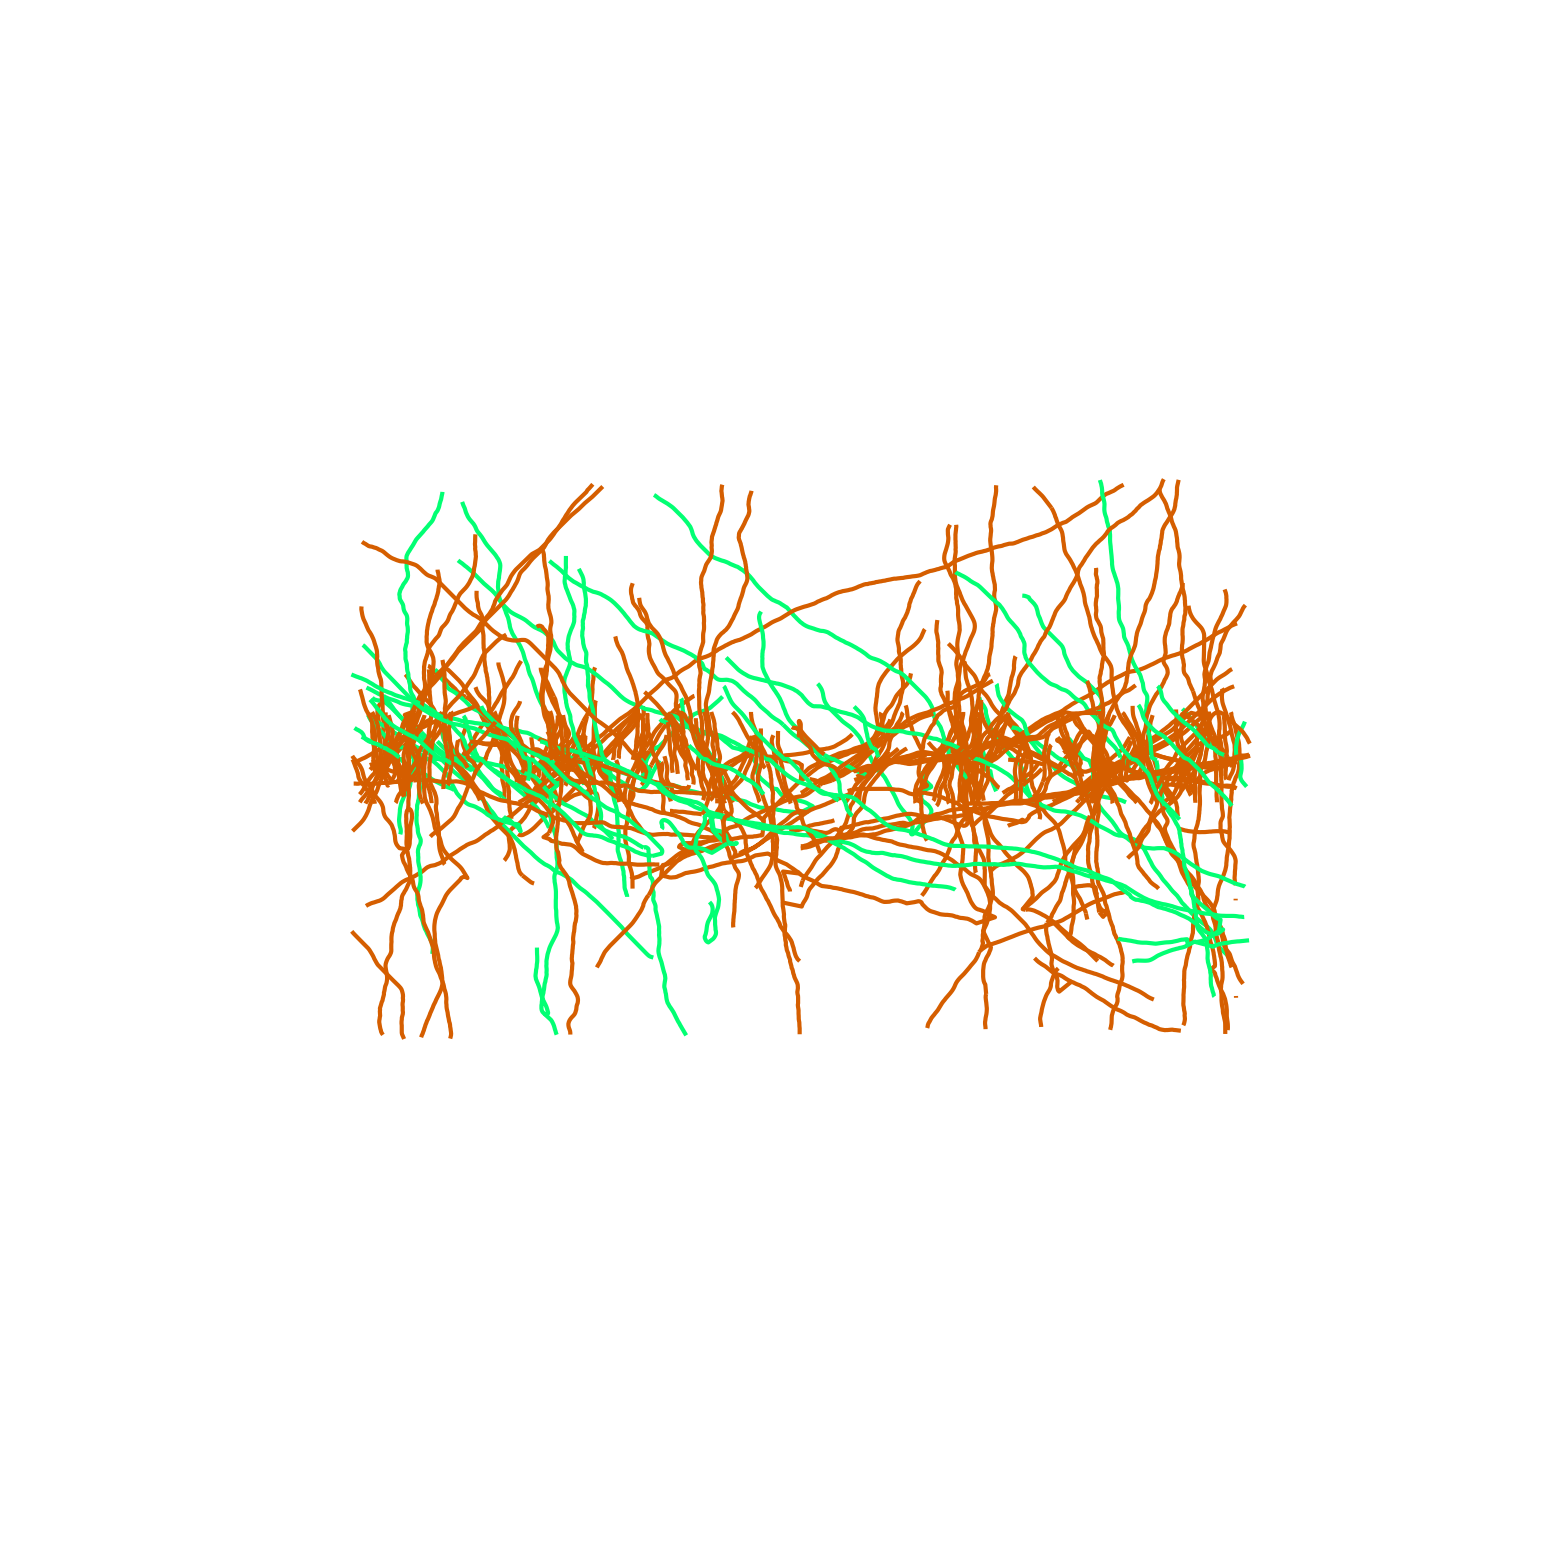

In [28]:
#plt.rcParams['axes.facecolor'] = 'black'
fig, ax = filt_vol.plot2d(figsize=(20,20),colors=filt_vol.color,lw=3,method='3d_complex')
ax.azim, ax.elev = -90, -90
#fig.patch.set_facecolor('black')
#ax.set_facecolor('black')
#plt.show()
plt.savefig('foo.png', bbox_inches='tight',facecolor='none')

In [22]:
nonpair_ids = [pq[0] for pq in nonpairs_pq] + [pq[1] for pq in nonpairs_pq]

In [23]:
nonpairs = [i for i,neu in enumerate(filt_vol) if neu.id in nonpair_ids]

Plot neurons:   0%|          | 0/46 [00:00<?, ?it/s]

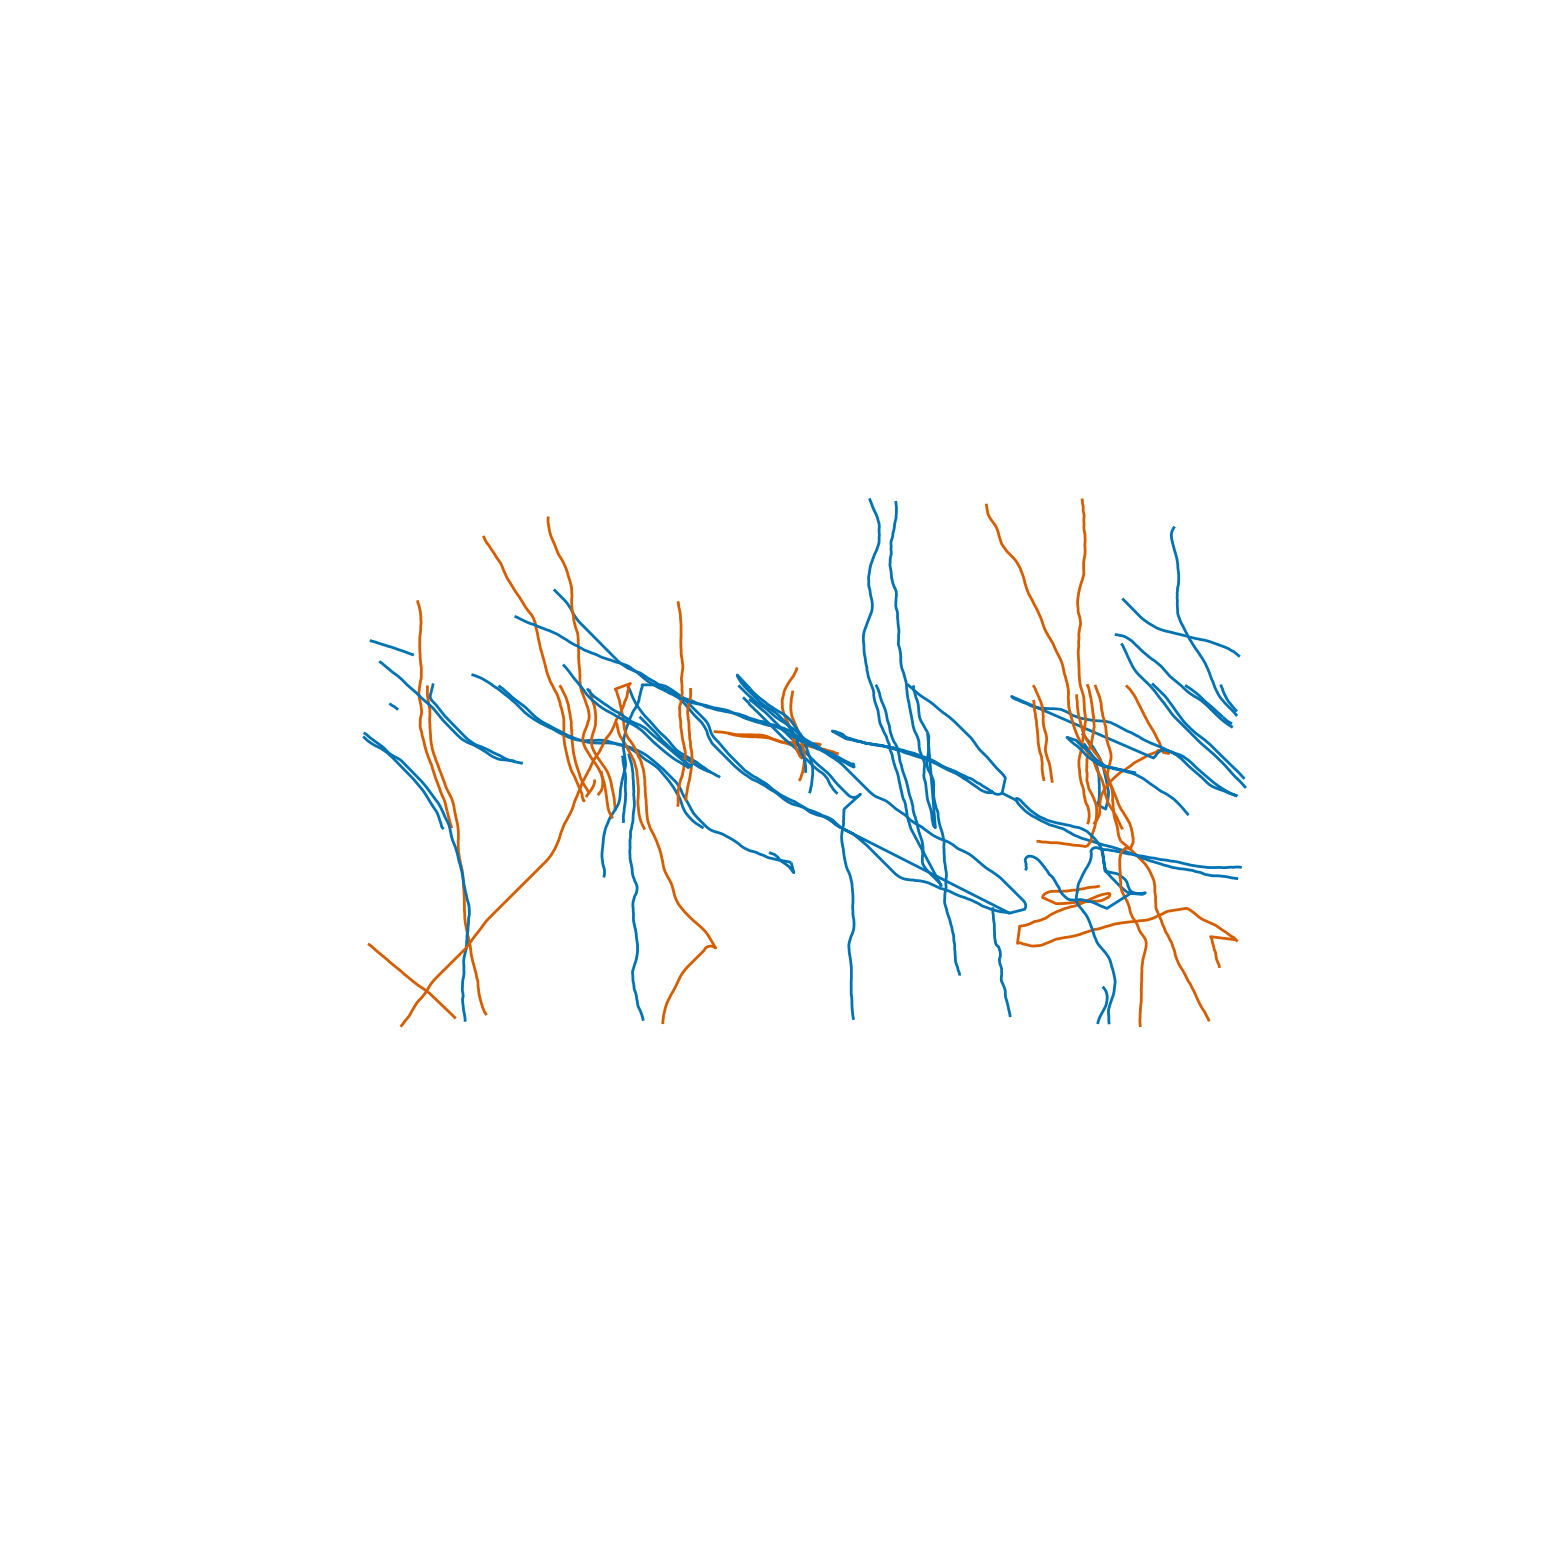

In [27]:
new_vol = filt_vol[filt_vol.strip == "merged"] + filt_vol[nonpairs]
new_labels = list((pd.Series(new_vol.strip)).map({'strip1':'#D55E00','strip2':'#D55E00','merged':'#0173B2'}))
new_vol.set_neuron_attributes(new_labels, 'color')
#plt.rcParams['axes.facecolor'] = 'black'
fig, ax = new_vol.plot2d(figsize=(20,20),colors=new_vol.color,lw=2,method='3d_complex')
ax.azim, ax.elev = -90, -90
#fig.patch.set_facecolor('black')
#ax.set_facecolor('black')
#plt.show()
plt.savefig('fooo.png', bbox_inches='tight',facecolor='none')

In [23]:
import plotly
fig = filt_vol.plot3d(backend="plotly",inline=False,color = filt_vol.strip, radius=True)
plotly.offline.plot(fig, filename='./new_merge_staged.html')

INFO  : Use the `.show()` method to plot the figure. (navis)


'./new_merge_staged.html'